### MINIST 예제 (CNN모델 예제)

In [ ]:
# 1. 필요한 라이브러리 임포트
import tensorflow as tf  # 딥러닝 라이브러리
from tensorflow.keras import layers, models  # 신경망 계층 및 모델 설계
from tensorflow.keras.datasets import mnist  # MNIST 데이터셋
import matplotlib.pyplot as plt  # 시각화 도구

In [ ]:
# 폰트지정
plt.rcParams['font.family'] = 'Malgun Gothic'

# 마이너스 부호 깨짐 지정
plt.rcParams['axes.unicode_minus'] = False

In [ ]:
# 2. 데이터 로드 및 전처리
# MNIST 데이터셋은 이미 나뉘어 제공 (학습/테스트 데이터)
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 28, 28)
(10000, 28, 28)


In [ ]:
# MNIST 이미지는 28x28 크기, 채널 정보 추가 (흑백 이미지는 채널 1개, 컬러는 3개)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1)).astype('float32') / 255.0  # 0~1로 정규화, 픽셀은 0에서 255까지 값을 가짐
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1)).astype('float32') / 255.0

In [ ]:
# 레이블을 One-Hot Encoding (숫자 0~9를 벡터로 변환) ex. 0 → [1, 0, 0, 0, 0, 0, 0, 0, 0, 0]
# One-Hot Encoding : 범주형 데이터를 수치형 데이터로 변환하는 방법
if len(y_train.shape) == 1:  # shape이 (n,)인지 확인
    y_train = tf.keras.utils.to_categorical(y_train, 10)  # to_categorical(원핫인코딩 대상, 클래스 갯수)
if len(y_test.shape) == 1:  # shape이 (n,)인지 확인
    y_test = tf.keras.utils.to_categorical(y_test, 10)

In [ ]:
# 3. CNN 모델 정의
model = models.Sequential()  # 순차적 모델 선언

In [ ]:
# 첫 번째 합성곱 계층: 필터 크기 3x3, 필터 수 32, 활성화 함수 ReLU
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
# 풀링 계층: 2x2 크기로 다운샘플링
model.add(layers.MaxPooling2D((2, 2)))

In [ ]:
# 두 번째 합성곱 계층: 필터 수 64
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

In [ ]:
# 세 번째 합성곱 계층: 필터 수 64
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

In [ ]:
# Fully Connected Layer를 연결하기 위해 Flatten 처리
model.add(layers.Flatten())

In [ ]:
# Fully Connected Layer 1: 뉴런 수 64, 활성화 함수 ReLU
model.add(layers.Dense(64, activation='relu'))

In [ ]:
# 출력층: 뉴런 수 10(클래스 수), 활성화 함수 Softmax
model.add(layers.Dense(10, activation='softmax'))

In [ ]:
# 모델 요약 출력 (구조 확인용)
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 26, 26, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 5, 5, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 3, 3, 64)            │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 576)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,770 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 61,514 (240.29 KB)

 Trainable params: 61,514 (240.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# 4. 모델 컴파일
model.compile(optimizer='adam',               # 최적화 알고리즘 (손실값을 최소화하면서 모델이 최적의 가중치를 찾도록 안내하는 역할)
              loss='categorical_crossentropy', # 다중 클래스 분류, to_categorical 원핫인코딩 전처리 필요   cf. 이진분류 : loss='binary_crossentropy'
              metrics=['accuracy'])           # 평가 지표: 정확도

In [ ]:
# 5. 모델 학습
history = model.fit(x_train, y_train, epochs=5, batch_size=64, validation_split=0.2)

Epoch 1/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 51s 64ms/step - accuracy: 0.8578 - loss: 0.4787 - val_accuracy: 0.9799 - val_loss: 0.0690
Epoch 2/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 78s 59ms/step - accuracy: 0.9787 - loss: 0.0639 - val_accuracy: 0.9836 - val_loss: 0.0549
Epoch 3/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 85s 63ms/step - accuracy: 0.9875 - loss: 0.0391 - val_accuracy: 0.9868 - val_loss: 0.0491
Epoch 4/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 80s 60ms/step - accuracy: 0.9905 - loss: 0.0291 - val_accuracy: 0.9867 - val_loss: 0.0440
Epoch 5/5
750/750 ━━━━━━━━━━━━━━━━━━━━ 45s 60ms/step - accuracy: 0.9922 - loss: 0.0243 - val_accuracy: 0.9848 - val_loss: 0.0479


In [ ]:
# 6. 모델 평가
test_loss, test_acc = model.evaluate(x_test, y_test)
print(f"테스트 정확도: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9837 - loss: 0.0462
테스트 정확도: 0.9874


In [ ]:
# 7. 결과 확인: 테스트 데이터에서 임의의 이미지 예측
import numpy as np

In [ ]:
# 테스트 데이터에서 첫 번째 샘플을 가져옴
sample_image = x_test[0]   # 첫번 째 이미지 저장
sample_label = np.argmax(y_test[0])   # y_test[0] 배열에서 가장 큰 값을 가지는 요소의 인덱스를 찾아 sample_label 변수에 저장
# 참고 : y_test[0] = [0.01, 0.02, 0.05, 0.88, 0.01, 0.01, 0.01, 0.00, 0.01, 0.00]일 때 np.argmax(y_test[0])는 3을 반환

In [ ]:
# 모델로 예측 수행
predicted_label = np.argmax(model.predict(sample_image.reshape(1, 28, 28, 1)))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 49892 (\N{HANGUL SYLLABLE SIL}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 51228 (\N{HANGUL SYLLABLE JE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 44050 (\N{HANGUL SYLLABLE GABS}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.10/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from current font.
  fig.canvas.print_figure(bytes_io, **kw)


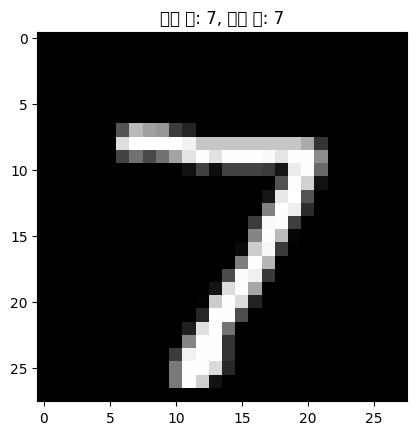

In [ ]:
# 결과 출력
plt.imshow(sample_image.reshape(28, 28), cmap='gray')
plt.title(f"real value: {sample_label}, forcast value: {predicted_label}")
plt.show()